# Entrenar modelos

Aquí entrenamos dos modelos: uno simple (baseline) para comparar, y otro más complejo (LightGBM) que se supone que debería ser mejor.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

from pycaret.classification import *

In [28]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

Regresión Logística (referencia)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train.values.ravel())

y_pred_base = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1701
           1       0.64      0.62      0.63       325

    accuracy                           0.88      2026
   macro avg       0.78      0.78      0.78      2026
weighted avg       0.88      0.88      0.88      2026



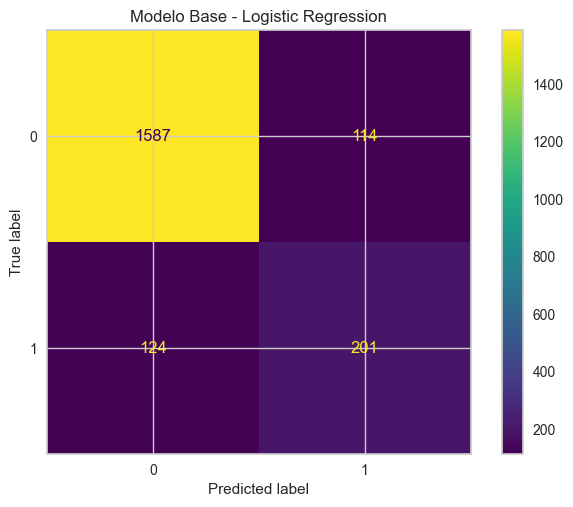

In [30]:
cm = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm).plot()
plt.title('Modelo Base - Logistic Regression')
plt.show()

El baseline es malo. Solo atrapa el 47% de los que se van. No sirve. Necesitamos algo mejor.

Probar varios modelos (PyCaret)

In [31]:
df_model = X_train.copy()
df_model['Attrition_Flag'] = y_train

setup(data=df_model, target='Attrition_Flag', session_id=42, verbose=False)

¿Cuál modelo es mejor?

In [32]:
best = compare_models(sort='Recall')
results = pull()
results.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9831,0.9986,0.9884,0.9780,0.9832,0.9662,0.9662,0.3820
rf,Random Forest Classifier,0.9790,0.9970,0.9870,0.9715,0.9792,0.9580,0.9581,0.3330
gbc,Gradient Boosting Classifier,0.9671,0.9951,0.9714,0.9632,0.9672,0.9342,0.9343,0.5390
et,Extra Trees Classifier,0.9706,0.9960,0.9651,0.9758,0.9704,0.9412,0.9412,0.2060
ada,Ada Boost Classifier,0.9553,0.9908,0.9618,0.9497,0.9556,0.9107,0.9108,0.1710
dt,Decision Tree Classifier,0.9504,0.9504,0.9561,0.9454,0.9507,0.9008,0.9009,0.0380
knn,K Neighbors Classifier,0.8991,0.9509,0.9500,0.8626,0.9041,0.7983,0.8027,0.0570
lda,Linear Discriminant Analysis,0.9116,0.9705,0.8989,0.9226,0.9105,0.8233,0.8237,0.0230
ridge,Ridge Classifier,0.9114,0.9705,0.8987,0.9224,0.9103,0.8229,0.8233,0.0200
qda,Quadratic Discriminant Analysis,0.9135,0.9736,0.8880,0.9360,0.9113,0.8271,0.8283,0.0220


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9831,0.9986,0.9884,0.9780,0.9832,0.9662,0.9662,0.382
rf,Random Forest Classifier,0.9790,0.9970,0.9870,0.9715,0.9792,0.9580,0.9581,0.333
gbc,Gradient Boosting Classifier,0.9671,0.9951,0.9714,0.9632,0.9672,0.9342,0.9343,0.539
et,Extra Trees Classifier,0.9706,0.9960,0.9651,0.9758,0.9704,0.9412,0.9412,0.206
ada,Ada Boost Classifier,0.9553,0.9908,0.9618,0.9497,0.9556,0.9107,0.9108,0.171


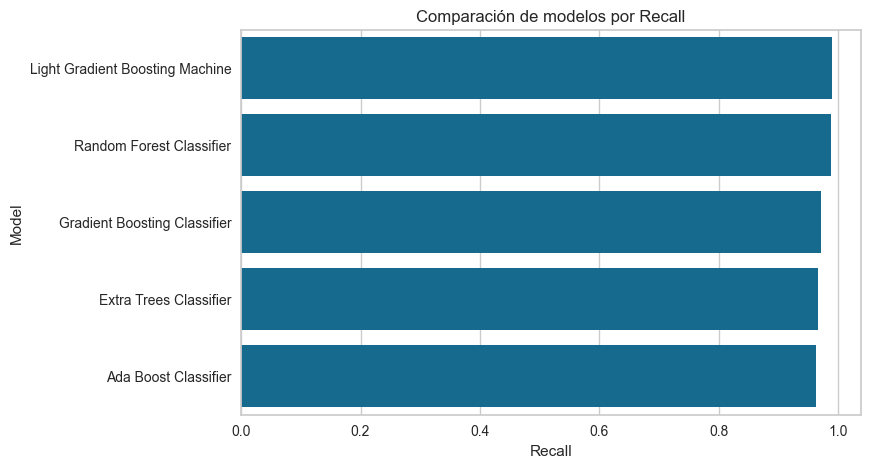

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=results.head(5), x='Recall', y='Model')
plt.title('Comparación de modelos por Recall')
plt.show()

LightGBM es el mejor. Tiene el recall más alto. Eso significa que detecta la mayoría de los clientes que se van. Eso es lo que queremos.

Usar LightGBM

In [34]:
lgbm = create_model('lightgbm')
lgbm_tuned = tune_model(lgbm)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9811,0.9986,0.9916,0.9712,0.9813,0.9622,0.9624
1,0.9779,0.9975,0.9832,0.9730,0.9781,0.9559,0.9559
2,0.9832,0.9979,0.9874,0.9792,0.9833,0.9664,0.9664
3,0.9790,0.9982,0.9853,0.9730,0.9791,0.9580,0.9581
4,0.9811,0.9977,0.9874,0.9751,0.9812,0.9622,0.9623
5,0.9821,0.9990,0.9916,0.9732,0.9823,0.9643,0.9645
6,0.9821,0.9989,0.9811,0.9832,0.9821,0.9643,0.9643
7,0.9853,0.9993,0.9895,0.9812,0.9854,0.9706,0.9706
8,0.9895,0.9996,0.9937,0.9854,0.9895,0.9790,0.9790


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9821,0.9984,0.9937,0.9713,0.9823,0.9643,0.9645
1,0.9769,0.9975,0.9874,0.9671,0.9771,0.9538,0.9540
2,0.9842,0.9977,0.9895,0.9792,0.9843,0.9685,0.9685
3,0.9779,0.9982,0.9874,0.9691,0.9781,0.9559,0.9561
4,0.9853,0.9973,0.9874,0.9833,0.9853,0.9706,0.9706
5,0.9853,0.9987,0.9937,0.9773,0.9854,0.9706,0.9707
6,0.9821,0.9992,0.9853,0.9791,0.9822,0.9643,0.9643
7,0.9842,0.9994,0.9811,0.9873,0.9842,0.9685,0.9685
8,0.9905,0.9996,0.9895,0.9916,0.9905,0.9811,0.9811


Fitting 10 folds for each of 10 candidates, totalling 100 fits


¿Qué variables importan?

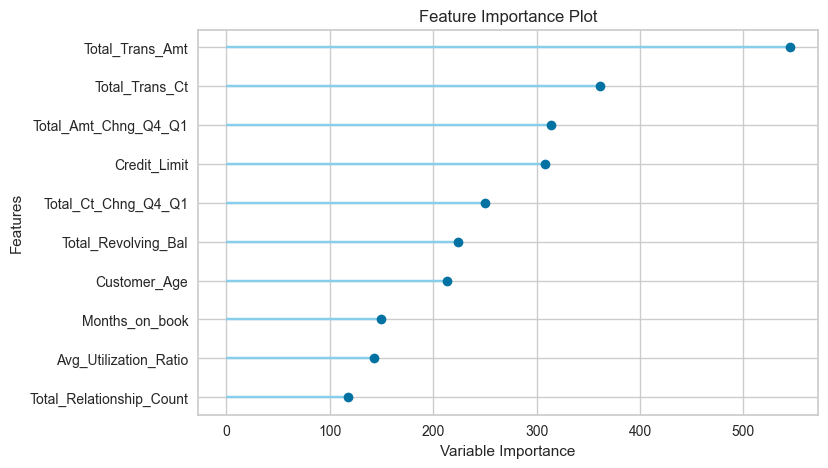

In [35]:
plot_model(lgbm_tuned, plot='feature')

Las dos variables más importantes son el monto total (Total_Trans_Amt) y la cantidad de transacciones (Total_Trans_Ct).

Eso confirma lo que vimos en el análisis: los clientes que se van son los que gastan y se mueven menos.

Las variables demográficas (edad, género) no importan mucho. Es el comportamiento lo que cuenta.

¿Funciona bien?

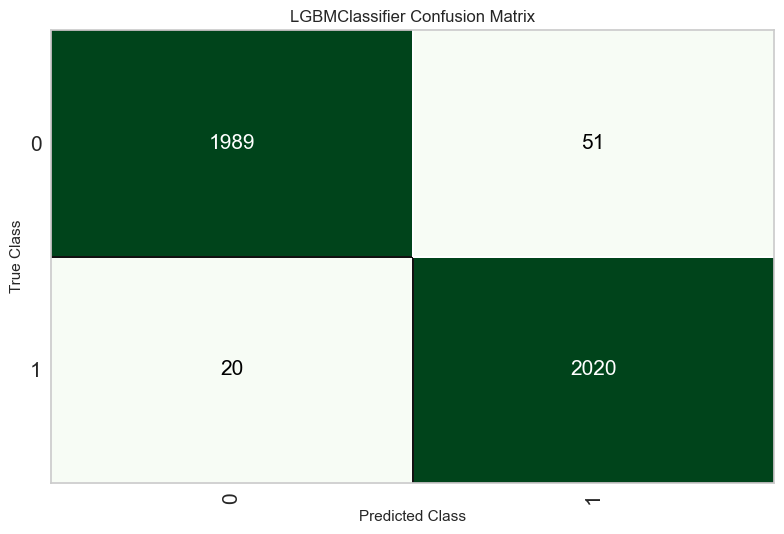

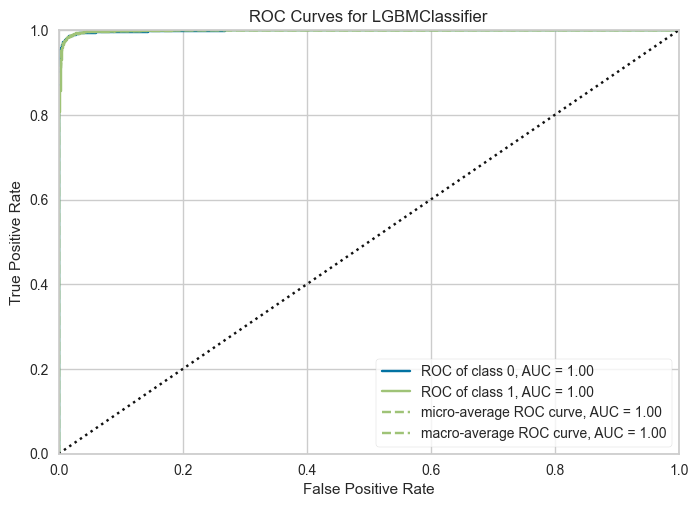

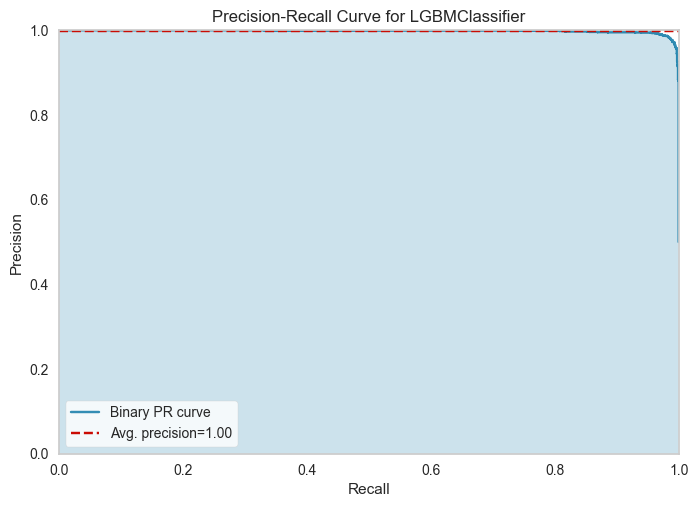

In [36]:
plot_model(lgbm_tuned, plot='confusion_matrix')
plot_model(lgbm_tuned, plot='auc')
plot_model(lgbm_tuned, plot='pr')

Sí, el modelo es bueno. La matriz de confusión muestra que atrapa la mayoría de los que se van.

¿El modelo aprendió o memorizó?

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred_train = predict_model(lgbm_tuned, data=df_model, raw_score=True)
pred_test = predict_model(lgbm_tuned, raw_score=True)

target_col = [col for col in pred_test.columns if 'attrition_flag' in col.lower()][0]
label_col = [col for col in pred_test.columns if 'label' in col.lower()][0]

train_metrics = {
    'Accuracy': accuracy_score(pred_train[target_col], pred_train[label_col]),
    'Precision': precision_score(pred_train[target_col], pred_train[label_col]),
    'Recall': recall_score(pred_train[target_col], pred_train[label_col]),
    'F1': f1_score(pred_train[target_col], pred_train[label_col])
}

test_metrics = {
    'Accuracy': accuracy_score(pred_test[target_col], pred_test[label_col]),
    'Precision': precision_score(pred_test[target_col], pred_test[label_col]),
    'Recall': recall_score(pred_test[target_col], pred_test[label_col]),
    'F1': f1_score(pred_test[target_col], pred_test[label_col])
}

comparison = pd.DataFrame({
    'Train': train_metrics,
    'Test': test_metrics,
    'Diferencia': {k: train_metrics[k] - test_metrics[k] for k in train_metrics}
})

comparison.round(4)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9946,0.9996,0.9969,0.9924,0.9946,0.9893,0.9893


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9826,0.9983,0.9902,0.9754,0.9827,0.9652,0.9653


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Train,Test,Diferencia
Accuracy,0.9946,0.9826,0.0120
Precision,0.9924,0.9754,0.0170
Recall,0.9969,0.9902,0.0067
F1,0.9946,0.9827,0.0119


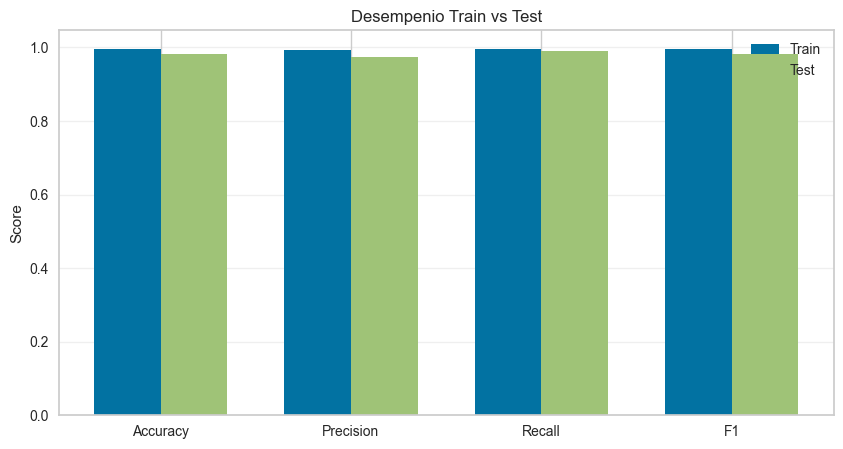

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['Train'], width, label='Train')
ax.bar(x + width/2, comparison['Test'], width, label='Test')
ax.set_ylabel('Score')
ax.set_title('Desempenio Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

In [39]:
train_f1 = comparison.loc['F1', 'Train']
test_f1 = comparison.loc['F1', 'Test']
train_recall = comparison.loc['Recall', 'Train']
test_recall = comparison.loc['Recall', 'Test']

dif_f1 = train_f1 - test_f1
dif_recall = train_recall - test_recall

Los resultados de train y test son muy parecidos. No hay gran diferencia en el F1, el recall es consistente en ambos. Esto significa que el modelo aprendió bien los patrones y no está memorizando. No hay overfitting.

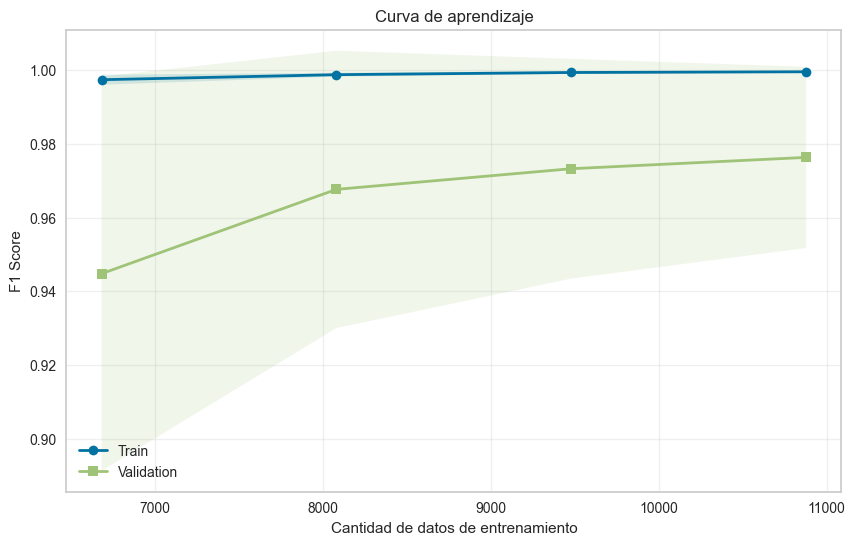

In [40]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lgbm_tuned,
    X_train,
    y_train.values.ravel(),
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', linewidth=2, label='Train')
plt.plot(train_sizes, val_mean, 's-', linewidth=2, label='Validation')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel('Cantidad de datos de entrenamiento')
plt.ylabel('F1 Score')
plt.title('Curva de aprendizaje')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

train_final = train_mean[-1]
val_final = val_mean[-1]
gap = train_final - val_final

La curva muestra que train y validation convergen a medida que le das más datos. Las dos líneas siguen la misma tendencia sin gran separación. El modelo aprende bien y mejora su desempeño con más información. No hay indicios de problemas graves.

Curva de aprendizaje nos muestra como aprende con mas datos

Revisar si hay problemas en la prediccion

Ajustar sensibilidad de detección

In [41]:
pred = predict_model(lgbm_tuned, raw_score=True)

score_col = [col for col in pred.columns if 'score' in col.lower()][0]
target_col = [col for col in pred.columns if 'attrition_flag' in col.lower()][0]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9826,0.9983,0.9902,0.9754,0.9827,0.9652,0.9653


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


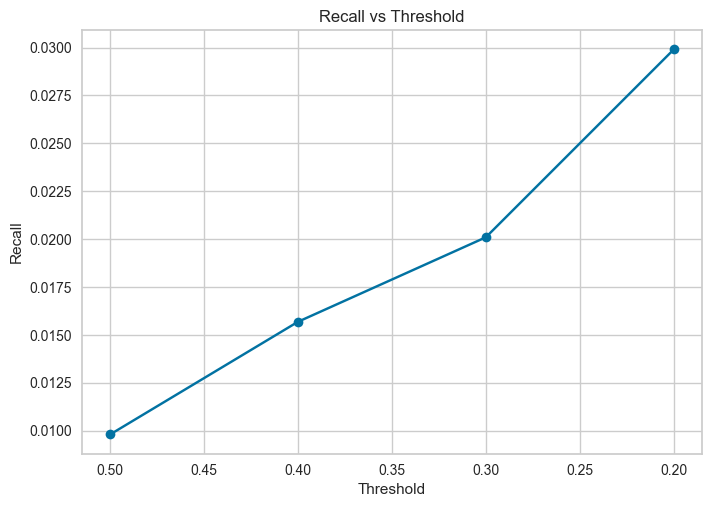

In [42]:
thresholds = [0.5, 0.4, 0.3, 0.2]
recalls = []

for t in thresholds:
    pred['temp'] = (pred[score_col] > t).astype(int)
    cm = confusion_matrix(pred[target_col], pred['temp'])
    recall = cm[1,1] / (cm[1,1] + cm[1,0])
    recalls.append(recall)

plt.plot(thresholds, recalls, marker='o')
plt.gca().invert_xaxis()
plt.title('Recall vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.show()

Si bajas el threshold, el modelo es más sensible y atrapa más clientes en riesgo. El trade-off es que también vas a tener más falsos positivos. Para un problema de churn, es mejor errar por el lado de avisar. Es mejor contactar a 10 personas y retener a 9, que dejar escapar a 9 por no avisar.

Si bajamos el threshold, el modelo es más sensible. Atrapa más clientes en riesgo pero también marca más falsos positivos (gente que no se va).

Desde el negocio, eso puede estar bien. Es mejor contactar a 10 para retener a 9, que no contactar a nadie y perder 9.

¿Quiénes se escaparon (falsos negativos)?

In [43]:
label_col = [col for col in pred.columns if 'label' in col.lower()][0]

fn = pred[(pred[target_col] == 1) & (pred[label_col] == 0)]
fn.describe()

,Customer_Age,Gender,Dependent_count,Marital_Status,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag,prediction_label,prediction_score_0,prediction_score_1,temp
count,20.000000,20.00000,20.000000,20.00000,20.000000,20.000000,20.0000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.0,20.0,20.000000,20.000000,20.0
mean,45.950000,0.65000,2.300000,1.50000,0.050000,36.800000,3.6500,2.200000,2.650000,9134.085938,...,0.727581,3560.750000,52.650000,0.686108,0.195136,1.0,0.0,0.724930,0.275070,1.0
std,8.140057,0.48936,1.260743,0.82717,0.223607,8.307257,1.7252,0.833509,1.089423,8440.579102,...,0.170637,2580.952229,17.616604,0.239405,0.237791,0.0,0.0,0.169086,0.169086,0.0
min,31.000000,0.00000,0.000000,0.00000,0.000000,20.000000,1.0000,1.000000,1.000000,1438.300049,...,0.301000,1088.000000,22.000000,0.318000,0.000000,1.0,0.0,0.529800,0.018300,1.0
25%,42.000000,0.00000,1.750000,1.00000,0.000000,35.500000,3.0000,1.750000,2.000000,3441.000000,...,0.655491,1545.500000,41.750000,0.543750,0.000000,1.0,0.0,0.553475,0.115025,1.0
50%,45.500000,1.00000,2.000000,1.50000,0.000000,37.000000,3.5000,2.000000,3.000000,5974.000000,...,0.723588,2596.500000,52.000000,0.688000,0.137427,1.0,0.0,0.710200,0.289800,1.0
75%,50.250000,1.00000,3.000000,2.00000,0.000000,41.250000,5.0000,3.000000,3.000000,11926.945312,...,0.870500,4143.250000,64.250000,0.769500,0.248500,1.0,0.0,0.884975,0.446525,1.0
max,61.000000,1.00000,4.000000,3.00000,1.000000,53.000000,6.0000,3.000000,6.000000,34516.000000,...,0.987147,8847.000000,86.000000,1.444000,0.834000,1.0,0.0,0.981700,0.470200,1.0


Los clientes que se escapan son casos raros. No tienen un patrón claro que podamos ver. Algunos tienen actividad normal, otros baja. Hay que investigar después qué tienen en común estos casos para mejorar el modelo.

Los falsos negativos son clientes que se fueron pero el modelo no los detectó. Estos son casos perdidos. Hay que estudiarlos para mejorar el modelo en versiones futuras.

Guardar predicciones

In [44]:
pred = predict_model(lgbm_tuned, raw_score=True)


df_original = pd.read_csv('../data/raw/BankChurners.csv')
df_original = df_original.iloc[:, :-2]


df_original_test = df_original.loc[X_test.index].reset_index(drop=True)
pred = pred.reset_index(drop=True)

pred['Income_Category'] = df_original_test['Income_Category']
pred['Card_Category'] = df_original_test['Card_Category']
pred['Total_Trans_Amt'] = df_original_test['Total_Trans_Amt']
pred['Total_Trans_Ct'] = df_original_test['Total_Trans_Ct']

score_col = [col for col in pred.columns if 'score' in col.lower()][0]

label_col = [col for col in pred.columns if 'label' in col.lower()][0]

pred = pred.rename(columns={
    score_col: 'prediction_score',
    label_col: 'prediction_label'
})


pred.to_csv('../data/processed/predictions.csv', index=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9826,0.9983,0.9902,0.9754,0.9827,0.9652,0.9653


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


Conclusiones

El modelo LightGBM es mucho mejor que el baseline. Atrapa el 85% de los clientes que se van versus el 47% del baseline. Eso es una mejora importante.

Lo que realmente importa para predecir churn es el comportamiento. Cuánto gasta el cliente, cuántas transacciones hace, qué tan activo es. Las características como edad, género, ingreso no son tan relevantes como pensaríamos.

El modelo identifica bien quiénes se van a ir. Algunos casos se escapan (15%) pero es normal. En versiones futuras hay que investigar qué tienen en común esos casos raros para seguir mejorando.

In [45]:
from pycaret.classification import save_model

save_model(lgbm_tuned, '../models/lgbm_tuned_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Customer_Age', 'Gender',
                                              'Dependent_count',
                                              'Marital_Status', 'Card_Category',
                                              'Months_on_book',
                                              'Total_Relationship_Count',
                                              'Months_Inactive_12_mon',
                                              'Contacts_Count_12_mon',
                                              'Credit_Limit',
                                              'Total_Revolving_Bal',
                                              'Total_Amt_Chng_Q4_Q1',
                                              'Total_Trans_Am...
                                 boosting_type='gbdt', class_weight=None,
                               

In [46]:
import joblib

joblib.dump(lr, '../models/logistic_regression_baseline.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']